In [1]:
import pandas as pd, numpy as np, os
pd.set_option('display.max_columns',False)
pd.set_option('display.max_rows',False)
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
import seaborn  as sns
import matplotlib.pyplot as plt
print('done!')

done!


In [2]:
#stratifyied sample

data = sns.load_dataset("titanic");print(data.shape)
data.head(3)

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [3]:
def qbinn(df,col,n):
    df[col+"_bin"] = pd.qcut(df[col],duplicates='drop',q=n)
    return df

#fare and age
print(data.age.isnull().sum(),data.fare.isnull().sum())
data.age.fillna(data['age'].median(),inplace=True)
print(data.age.isnull().sum(),data.fare.isnull().sum())

qbinn(data,'age',5)
qbinn(data,'fare',5)

scol=['age_bin','fare_bin']

ds,_ = train_test_split(data,test_size=0.7,stratify=data[scol],random_state=1181)
print(ds.shape,data.shape)

print(data.age_bin.value_counts()/data.shape[0]*100,data.fare_bin.value_counts()/data.shape[0]*100)
print(ds.age_bin.value_counts()/ds.shape[0]*100,ds.fare_bin.value_counts()/ds.shape[0]*100)

177 0
0 0
(267, 17) (891, 17)
age_bin
(20.0, 28.0]     40.404040
(0.419, 20.0]    20.089787
(38.0, 80.0]     19.865320
(28.0, 38.0]     19.640853
Name: count, dtype: float64 fare_bin
(7.854, 10.5]        20.650954
(21.679, 39.688]     20.202020
(-0.001, 7.854]      20.089787
(39.688, 512.329]    19.753086
(10.5, 21.679]       19.304153
Name: count, dtype: float64
age_bin
(20.0, 28.0]     40.449438
(0.419, 20.0]    19.850187
(28.0, 38.0]     19.850187
(38.0, 80.0]     19.850187
Name: count, dtype: float64 fare_bin
(7.854, 10.5]        20.973783
(21.679, 39.688]     20.224719
(-0.001, 7.854]      19.850187
(39.688, 512.329]    19.850187
(10.5, 21.679]       19.101124
Name: count, dtype: float64


In [4]:
#logistic regr
df = pd.read_csv("ultimate_student_productivity_dataset_5000.csv");print(df.shape) 
df.head(3)

(5000, 21)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,27.39,34.37,45.15,18.30


In [5]:
cat = []

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if col not in ['studend_id','exam_score']:
        if df[col].dtype == object:
            cat.append(col)
            print("{} is categorical".format(col))
print(cat)

for col in cat:
    df[col+"_enc"] = le.fit_transform(df[col])
    print("{} is transformed".format(col))

dfx = df.drop(cat,axis=1)
dfx.columns    

gender is categorical
academic_level is categorical
internet_quality is categorical
['gender', 'academic_level', 'internet_quality']
gender is transformed
academic_level is transformed
internet_quality is transformed


Index(['student_id', 'age', 'study_hours', 'self_study_hours',
       'online_classes_hours', 'social_media_hours', 'gaming_hours',
       'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'mental_health_score', 'focus_index', 'burnout_level',
       'productivity_score', 'exam_score', 'gender_enc', 'academic_level_enc',
       'internet_quality_enc'],
      dtype='object')

Index(['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
       'social_media_hours', 'gaming_hours', 'sleep_hours',
       'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
       'part_time_job', 'upcoming_deadline', 'mental_health_score',
       'focus_index', 'burnout_level', 'productivity_score'],
      dtype='object')


<Axes: >

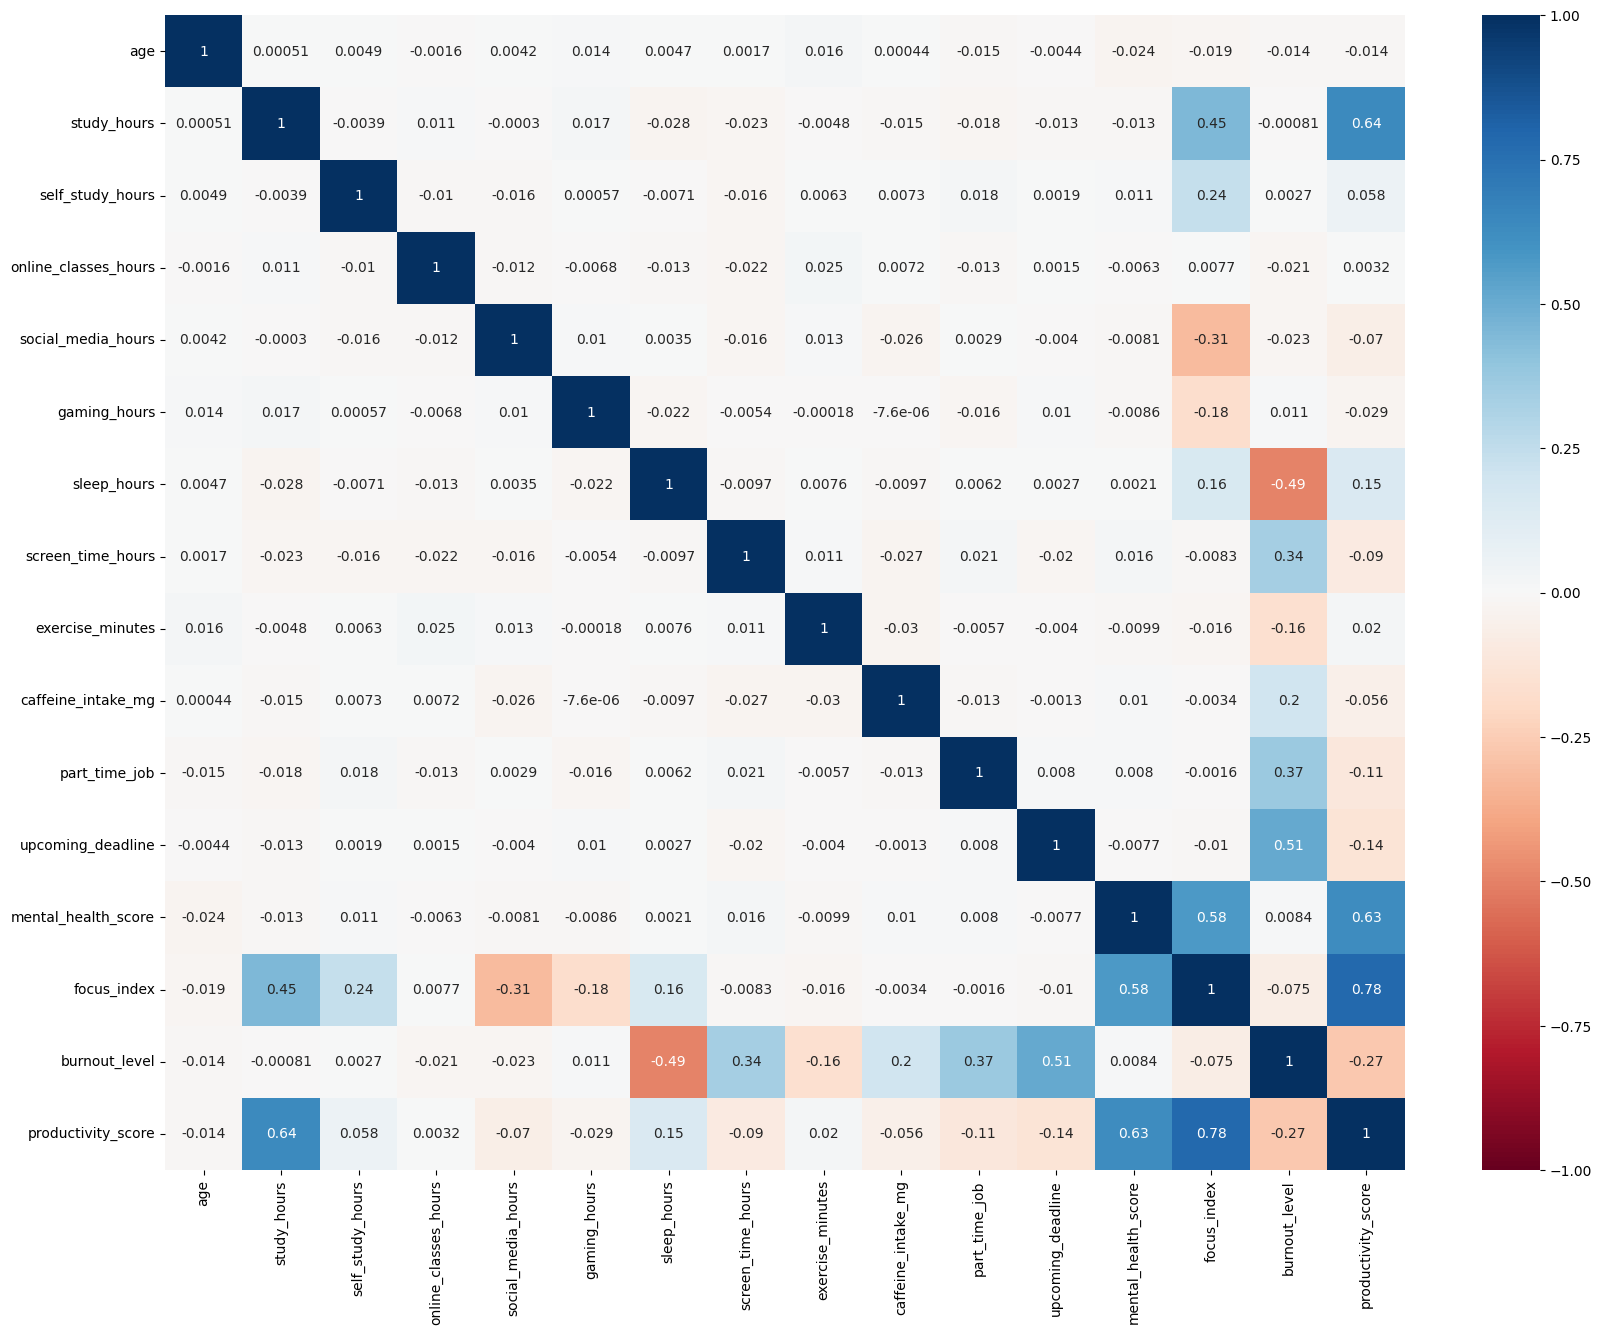

In [6]:
#corr matrix
dft = dfx.drop(['student_id','exam_score','gender_enc', 'academic_level_enc',
       'internet_quality_enc'],axis=1)
print(dft.columns)
#########

plt.figure(figsize=(20,15))
sns.heatmap(dft.corr(method='pearson'),vmin=-1,cmap='RdBu',annot=True)

In [7]:
#vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

X = dfx.drop(['student_id','exam_score'],axis=1)
print(X.columns,X.shape)
X1 = add_constant(X)

vif=[]
for nos in range(len(X1.columns)):
    var = X1.columns[nos]
    viff = variance_inflation_factor(X1.values,nos)
    res = var,viff
    vif.append(res)

vifd = pd.DataFrame(vif,columns=['variable','vif_value'])
vifd.head(10)

Index(['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
       'social_media_hours', 'gaming_hours', 'sleep_hours',
       'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
       'part_time_job', 'upcoming_deadline', 'mental_health_score',
       'focus_index', 'burnout_level', 'productivity_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc'],
      dtype='object') (5000, 19)


,variable,vif_value
0,const,237.655275
1,age,1.002190
2,study_hours,5.220923
3,self_study_hours,1.211079
4,online_classes_hours,1.004057
5,social_media_hours,1.370582
6,gaming_hours,1.121585
7,sleep_hours,2.476995
8,screen_time_hours,1.674227
9,exercise_minutes,1.124025


In [8]:
# remove
colkill = ["mental_health_score", "focus_index", "study_hours","student_id"]
dfx = dfx.drop(colkill,axis=1)
dfx.columns

Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'exam_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc'],
      dtype='object')

In [9]:
#logistic regr
from sklearn.linear_model import LogisticRegression
dfx['target'] = np.where(dfx['exam_score']>dfx['exam_score'].quantile([0.75]).item(),1,0)
print(dfx.target.value_counts(normalize=True))
      
X = dfx.drop(['target','exam_score'],axis=1)
y = dfx['target'].copy()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1181)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)
print(X_train.columns)

lr = LogisticRegression(fit_intercept=True,random_state=1181)
#grid search
from sklearn.model_selection import GridSearchCV
grid = {'penalty':['l1','l2'],
         'solver':['lbfgs','liblinear'],
       'max_iter':[50,100]}
lrcv = GridSearchCV(estimator=lr, param_grid=grid,cv=5)
lrcv.fit(X_train,y_train)
print(lrcv.best_score_)
print(lrcv.best_params_)

target
0    0.7504
1    0.2496
Name: proportion, dtype: float64
(3500, 16) (1500, 16) (3500,) (1500,)
Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc'],
      dtype='object')
0.9014285714285715
{'max_iter': 50, 'penalty': 'l1', 'solver': 'liblinear'}


In [10]:
lr = LogisticRegression(max_iter=50,penalty='l1',solver='liblinear',random_state=1181,fit_intercept=True)
lr.fit(X_train,y_train)
print('model fit!')

from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix,auc,precision_recall_curve
y_pred = lr.predict(X_test)

print(classification_report(y_test,y_pred))
a = pd.DataFrame(confusion_matrix(y_test,y_pred),columns=['pred0','pred1'],index=['actual0','actual1'])
a

model fit!
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1125
           1       0.83      0.79      0.81       375

    accuracy                           0.91      1500
   macro avg       0.88      0.87      0.87      1500
weighted avg       0.91      0.91      0.91      1500



,pred0,pred1
actual0,1064,61
actual1,78,297


In [11]:
# gini and auc
y_pred_prob = lr.predict_proba(X_test)[:,1]
auc1 = roc_auc_score(y_test,y_pred_prob)
print(auc1,2*auc1-1)


# thresh opt
y_pred_train = lr.predict_proba(X_train)[:,1]
fpr,tpr,thresh = roc_curve(y_train,y_pred_train)

m = pd.concat([pd.DataFrame(fpr),pd.DataFrame(tpr),pd.DataFrame(thresh)],axis=1)
m.columns = ['fpr','tpr','thresh']
m['diff'] = m['tpr'] - m['fpr']
m[m['diff']==m['diff'].max()]

0.962330074074074 0.924660148148148


,fpr,tpr,thresh,diff
352,0.133993,0.911798,0.21828,0.777805


0.9055889351186439 0.8111778702372878


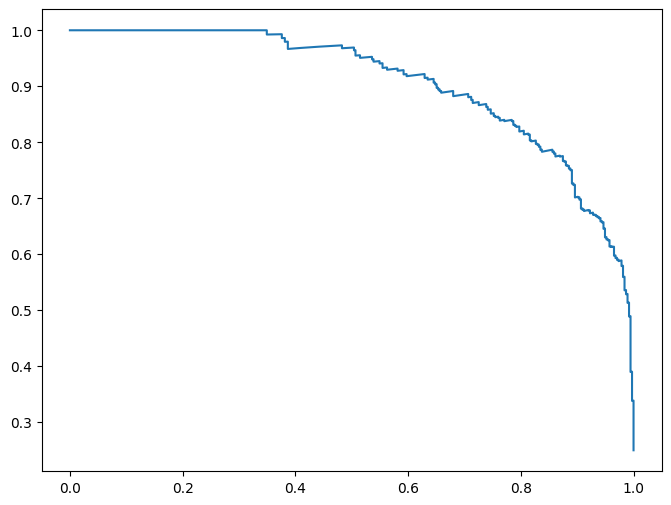

In [12]:
precision, recall, threshold = precision_recall_curve(y_test,y_pred_prob)
aucc = auc(recall, precision)
print(aucc,2*aucc-1)

plt.figure(figsize=(8,6))
plt.plot(recall,precision)


In [13]:
# load save and retest
import joblib as jb
print(os.getcwd())
path = r"D:\2026_s_tasks\works_2026\lr_jun1.joblib"
jb.dump(lr,path)
print("model saved!")

### load
lrr = jb.load(path)
print('model loaded!')
dfi = dfx.copy()
dfii = dfx.copy()
dfi = dfi[X_train.columns]
dfi.columns

D:\2026_s_tasks\works_2026
model saved!
model loaded!


Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc'],
      dtype='object')

In [14]:
qbinn(dfii,"exam_score",8)
qbinn(dfii,"productivity_score",8)
print(dfi.columns)

dfii['pred'] = lr.predict(dfi)
dfii.groupby(['exam_score_bin']).agg(target = pd.NamedAgg('target','sum'),
                                    predd = pd.NamedAgg('pred','sum'))

Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc'],
      dtype='object')


,target,predd
exam_score_bin,,
"(0.999, 2.959]",0,0
"(2.959, 9.338]",0,0
"(9.338, 13.85]",0,0
"(13.85, 18.01]",0,12
"(18.01, 22.52]",0,47
"(22.52, 27.4]",0,150
"(27.4, 33.52]",624,392
"(33.52, 64.09]",624,590


In [15]:
dfii.groupby(['productivity_score_bin']).agg(target = pd.NamedAgg('target','sum'),
                                    predd = pd.NamedAgg('pred','sum'))

,target,predd
productivity_score_bin,,
"(0.999, 17.546]",0,0
"(17.546, 25.29]",0,0
"(25.29, 31.56]",7,0
"(31.56, 36.86]",23,0
"(36.86, 42.774]",60,5
"(42.774, 49.142]",175,106
"(49.142, 57.292]",396,459
"(57.292, 98.02]",587,621


In [16]:
pd.crosstab(dfii['exam_score_bin'],dfii['productivity_score_bin'],
           values=dfii['pred'],aggfunc='sum',margins=True, margins_name='total')

productivity_score_bin,"(0.999, 17.546]","(17.546, 25.29]","(25.29, 31.56]","(31.56, 36.86]","(36.86, 42.774]","(42.774, 49.142]","(49.142, 57.292]","(57.292, 98.02]",total
exam_score_bin,,,,,,,,,
"(0.999, 2.959]",0,0,0,0,0,0,0,0,0
"(2.959, 9.338]",0,0,0,0,0,0,0,0,0
"(9.338, 13.85]",0,0,0,0,0,0,0,0,0
"(13.85, 18.01]",0,0,0,0,0,3,9,0,12
"(18.01, 22.52]",0,0,0,0,1,12,28,6,47
"(22.52, 27.4]",0,0,0,0,2,26,91,31,150
"(27.4, 33.52]",0,0,0,0,1,48,194,149,392
"(33.52, 64.09]",0,0,0,0,1,17,137,435,590
total,0,0,0,0,5,106,459,621,1191


In [17]:
pd.crosstab(dfii['exam_score_bin'],dfii['productivity_score_bin'],
           values=dfii['target'],aggfunc='sum',margins=True, margins_name='total')

productivity_score_bin,"(0.999, 17.546]","(17.546, 25.29]","(25.29, 31.56]","(31.56, 36.86]","(36.86, 42.774]","(42.774, 49.142]","(49.142, 57.292]","(57.292, 98.02]",total
exam_score_bin,,,,,,,,,
"(0.999, 2.959]",0,0,0,0,0,0,0,0,0
"(2.959, 9.338]",0,0,0,0,0,0,0,0,0
"(9.338, 13.85]",0,0,0,0,0,0,0,0,0
"(13.85, 18.01]",0,0,0,0,0,0,0,0,0
"(18.01, 22.52]",0,0,0,0,0,0,0,0,0
"(22.52, 27.4]",0,0,0,0,0,0,0,0,0
"(27.4, 33.52]",0,0,7,22,51,141,252,151,624
"(33.52, 64.09]",0,0,0,1,9,34,144,436,624
total,0,0,7,23,60,175,396,587,1248


In [18]:
#XGB
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=1181,eval_metric='logloss')

grid = {"objective":['binary:logistic','softprob','softprob'],
        "n_estimators":[50,100],
       "learning_rate":[0.01,0.05]}

xgbcv = GridSearchCV(estimator=xgb,param_grid=grid,cv=5)
xgbcv.fit(X_train,y_train)
print(xgbcv.best_params_)
print(xgbcv.best_score_)

{'learning_rate': 0.05, 'n_estimators': 100, 'objective': 'binary:logistic'}
0.8917142857142857


In [19]:
xgb = XGBClassifier(n_estimators=100,objective='binary:logistic',
                   learning_rate=0.05,eval_metric='logloss',random_state=1181)
xgb.fit(X_train,y_train)
y_xgb_pred = xgb.predict(X_test)

print(classification_report(y_test,y_xgb_pred))
a = pd.DataFrame(confusion_matrix(y_test,y_xgb_pred),columns=['pred0',"pred1"],
                index=['actual0','actual1'])
a

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1125
           1       0.83      0.78      0.80       375

    accuracy                           0.91      1500
   macro avg       0.88      0.86      0.87      1500
weighted avg       0.90      0.91      0.90      1500



,pred0,pred1
actual0,1067,58
actual1,84,291


In [20]:
# opt
y_pred_xgb = xgb.predict_proba(X_test)[:,1]
auc2 = roc_auc_score(y_test,y_pred_xgb)
print(auc2,2*auc2-1)

#threshold
ypred_train = xgb.predict_proba(X_train)[:,1]
fpr,tpr,thresh = roc_curve(y_train,ypred_train)
m = pd.concat([pd.DataFrame(fpr),pd.DataFrame(tpr),pd.DataFrame(thresh)],axis=1)
m.columns = ['fpr','tpr','thresh']
m['diff'] = m['tpr'] - m['fpr']
m[m['diff']==m['diff'].max()]


0.9564811851851851 0.9129623703703702


,fpr,tpr,thresh,diff
152,0.050247,0.969072,0.336087,0.918825


0.8911789502930416 0.7823579005860832


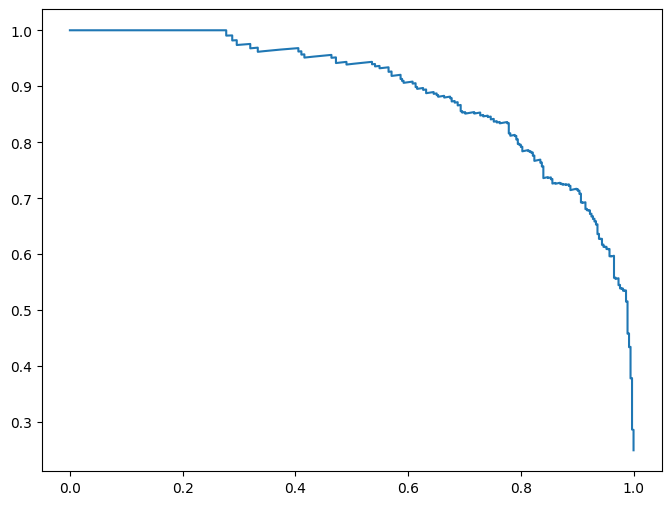

In [21]:
# pr auc
precision,recall,threshold = precision_recall_curve(y_test,y_pred_xgb)
auc3 = auc(recall,precision)
print(auc3,2*auc3-1)

plt.figure(figsize=(8,6))
plt.plot(recall,precision)

In [25]:
# load and repred
import joblib as jb
print(os.getcwd())
path = r"D:\2026_s_tasks\works_2026\xgb_jun1.joblib"

jb.dump(xgb,path)
print('model saved!')

#load!
xgbb = jb.load(path)
dfi = dfx.copy()
dfii = dfi.copy()
dfii = dfii[X_train.columns]
print(dfi.columns,dfii.columns)

D:\2026_s_tasks\works_2026
model saved!
Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'exam_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc', 'target'],
      dtype='object') Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc'],
      dtype='object')


In [27]:
dfi['pred_xgb'] = xgbb.predict(dfii)
qbinn(dfi,'exam_score',8)
qbinn(dfi,'productivity_score',8)
print(dfi.columns)

dfi.groupby(['exam_score_bin']).agg(targ = pd.NamedAgg('target','sum'),
                                   pred_xgb = pd.NamedAgg('pred_xgb','sum'))

Index(['age', 'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'burnout_level', 'productivity_score', 'exam_score', 'gender_enc',
       'academic_level_enc', 'internet_quality_enc', 'target', 'pred_xgb',
       'exam_score_bin', 'productivity_score_bin'],
      dtype='object')


,targ,pred_xgb
exam_score_bin,,
"(0.999, 2.959]",0,0
"(2.959, 9.338]",0,0
"(9.338, 13.85]",0,0
"(13.85, 18.01]",0,4
"(18.01, 22.52]",0,20
"(22.52, 27.4]",0,80
"(27.4, 33.52]",624,475
"(33.52, 64.09]",624,604


In [28]:
dfi.groupby(['productivity_score_bin']).agg(targ = pd.NamedAgg('target','sum'),
                                   pred_xgb = pd.NamedAgg('pred_xgb','sum'))

,targ,pred_xgb
productivity_score_bin,,
"(0.999, 17.546]",0,0
"(17.546, 25.29]",0,0
"(25.29, 31.56]",7,1
"(31.56, 36.86]",23,4
"(36.86, 42.774]",60,24
"(42.774, 49.142]",175,128
"(49.142, 57.292]",396,423
"(57.292, 98.02]",587,603


In [29]:
pd.crosstab(dfi['exam_score_bin'],dfi['productivity_score_bin'],values=dfi['target'],
           aggfunc='sum',margins=True,margins_name='totals')

productivity_score_bin,"(0.999, 17.546]","(17.546, 25.29]","(25.29, 31.56]","(31.56, 36.86]","(36.86, 42.774]","(42.774, 49.142]","(49.142, 57.292]","(57.292, 98.02]",totals
exam_score_bin,,,,,,,,,
"(0.999, 2.959]",0,0,0,0,0,0,0,0,0
"(2.959, 9.338]",0,0,0,0,0,0,0,0,0
"(9.338, 13.85]",0,0,0,0,0,0,0,0,0
"(13.85, 18.01]",0,0,0,0,0,0,0,0,0
"(18.01, 22.52]",0,0,0,0,0,0,0,0,0
"(22.52, 27.4]",0,0,0,0,0,0,0,0,0
"(27.4, 33.52]",0,0,7,22,51,141,252,151,624
"(33.52, 64.09]",0,0,0,1,9,34,144,436,624
totals,0,0,7,23,60,175,396,587,1248


In [30]:
pd.crosstab(dfi['exam_score_bin'],dfi['productivity_score_bin'],values=dfi['pred_xgb'],
           aggfunc='sum',margins=True,margins_name='totals')

productivity_score_bin,"(0.999, 17.546]","(17.546, 25.29]","(25.29, 31.56]","(31.56, 36.86]","(36.86, 42.774]","(42.774, 49.142]","(49.142, 57.292]","(57.292, 98.02]",totals
exam_score_bin,,,,,,,,,
"(0.999, 2.959]",0,0,0,0,0,0,0,0,0
"(2.959, 9.338]",0,0,0,0,0,0,0,0,0
"(9.338, 13.85]",0,0,0,0,0,0,0,0,0
"(13.85, 18.01]",0,0,0,0,0,1,3,0,4
"(18.01, 22.52]",0,0,0,0,0,6,12,2,20
"(22.52, 27.4]",0,0,0,0,0,18,45,17,80
"(27.4, 33.52]",0,0,1,4,19,81,221,149,475
"(33.52, 64.09]",0,0,0,0,5,22,142,435,604
totals,0,0,1,4,24,128,423,603,1183


In [33]:
lr.coef_,lr.intercept_,xgb.get_booster().get_score(importance_type='gain')

(array([[-2.95910380e-02,  1.40575006e-01,  5.64717254e-02,
         -1.72277503e-01, -1.43733154e-01,  5.77967016e-02,
          2.53994114e-02,  1.37651560e-04,  7.39860106e-04,
          1.71269216e-01,  9.44635929e-02, -7.08307343e-02,
          2.26504087e-01,  1.24999459e-01, -9.26396420e-02,
         -2.35110684e-02]]),
 array([-8.4096532]),
 {'age': 2.532231092453003,
  'self_study_hours': 2.704072952270508,
  'online_classes_hours': 2.5159358978271484,
  'social_media_hours': 3.226278781890869,
  'gaming_hours': 2.453249454498291,
  'sleep_hours': 2.774402141571045,
  'screen_time_hours': 2.6866965293884277,
  'exercise_minutes': 2.465146541595459,
  'caffeine_intake_mg': 2.137984275817871,
  'part_time_job': 2.1664979457855225,
  'upcoming_deadline': 2.814375638961792,
  'burnout_level': 4.901136875152588,
  'productivity_score': 40.93586730957031,
  'gender_enc': 2.5460712909698486,
  'academic_level_enc': 2.8200669288635254,
  'internet_quality_enc': 1.9437072277069092})

In [39]:
# sm OLS
import statsmodels.api as sm

X1 = sm.add_constant(X)
sml = sm.Logit(y,X1).fit()
sml.summary()

Optimization terminated successfully.
         Current function value: 0.215543
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4983
Method:                           MLE   Df Model:                           16
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.6164
Time:                        20:34:21   Log-Likelihood:                -1077.7
converged:                       True   LL-Null:                       -2809.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -10.3236      0.915    -11.288      0.000     -12.116      -8.531
age                     -0.0163      0.019     -0.848      0.397      -0.054       0.021
self_study_hours         0.1567      0.048      3.243      0.001       0.062       0.251
online_classes_hours     0.0638      0.056      1.143      0.253      -0.046       0.173
social_media_hours      -0.1596      0.037     -4.266      0.000      -0.233      -0.086
gaming_hours            -0.1443      0.050     -2.899      0.004      -0.242      -0.047
sleep_hours              0.1775      0.073      2.415      0.016       0.033       0.322
screen_time_hours        0.0310      0.029      1.067      0.286      -0.026       0.088
exercise_minutes         0.0010      0.001      0.721      0.471      -0.002       0.004
caffeine_intake_mg       0.0003      0.000      0.768      0.442      -0.001       0.001
part_time_job            0.0392      0.148      0.265      0.791      -0.251       0.329
upcoming_deadline       -0.0977      0.176     -0.556      0.578      -0.442       0.246
burnout_level           -0.0564      0.010     -5.900      0.000      -0.075      -0.038
productivity_score       0.2314      0.008     29.819      0.000       0.216       0.247
gender_enc               0.0747      0.068      1.096      0.273      -0.059       0.208
academic_level_enc      -0.0689      0.068     -1.012      0.311      -0.202       0.065
internet_quality_enc     0.0042      0.068      0.062      0.951      -0.129       0.138
========================================================================================
"""

In [40]:
#linear reg
y = dfx['exam_score'].copy()
smols = sm.OLS(y,X1).fit()
smols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     1443.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:35:43   Log-Likelihood:                -15251.
No. Observations:                5000   AIC:                         3.054e+04
Df Residuals:                    4983   BIC:                         3.065e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.1763      1.113      1.955      0.051      -0.006       4.359
age                      0.0011      0.025      0.045      0.964      -0.048       0.051
self_study_hours         0.3639      0.062      5.904      0.000       0.243       0.485
online_classes_hours    -0.0152      0.074     -0.206      0.837      -0.160       0.129
social_media_hours      -0.4227      0.050     -8.535      0.000      -0.520      -0.326
gaming_hours            -0.2949      0.065     -4.520      0.000      -0.423      -0.167
sleep_hours              0.2757      0.095      2.888      0.004       0.089       0.463
screen_time_hours        0.0023      0.038      0.060      0.952      -0.072       0.076
exercise_minutes        -0.0008      0.002     -0.440      0.660      -0.004       0.003
caffeine_intake_mg       0.0003      0.001      0.513      0.608      -0.001       0.001
part_time_job            0.0959      0.192      0.500      0.617      -0.280       0.472
upcoming_deadline       -0.2926      0.229     -1.279      0.201      -0.741       0.156
burnout_level           -0.1452      0.012    -12.010      0.000      -0.169      -0.122
productivity_score       0.5971      0.004    133.049      0.000       0.588       0.606
gender_enc              -0.0810      0.089     -0.905      0.365      -0.256       0.094
academic_level_enc       0.0374      0.089      0.420      0.675      -0.137       0.212
internet_quality_enc     0.0123      0.089      0.138      0.891      -0.163       0.188
==============================================================================
Omnibus:                        0.318   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.853   Jarque-Bera (JB):                0.320
Skew:                          -0.020   Prob(JB):                        0.852
Kurtosis:                       2.997   Cond. No.                     4.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
### create a df
dictt = {'students':['ani','abi','akash'],
        'marks':[50,60,70]}

dfmake = pd.DataFrame(dictt);dfmake

,students,marks
0,ani,50
1,abi,60
2,akash,70


In [54]:
words = ['data is the new world oil and data is everywhere']
print(words)

nwrds = words[0].lower().split()
print(nwrds)

w=[]
for word in nwrds:
    w.append(word)

dfw = pd.DataFrame(w,columns=['words'])
dfw.groupby('words').agg(wrd_count = pd.NamedAgg('words','count'))
    

['data is the new world oil and data is everywhere']
['data', 'is', 'the', 'new', 'world', 'oil', 'and', 'data', 'is', 'everywhere']


,wrd_count
words,
and,1
data,2
everywhere,1
is,2
new,1
oil,1
the,1
world,1
